In [1]:
import json

In [2]:
with open("2-processed/ustad_360_stem.json", "r") as f:
    data = json.load(f)

In [3]:
len(data)

13903

In [4]:
FINAL_DOMAINS = {"STEM", "Humanities", "Social Sciences", "Profession", "Other"}

In [5]:
unique_subdomains = set()
for item in data:
    unique_subdomains.add(item["subdomain"])

unique_subdomains

{'biology',
 'chemistry',
 'civics',
 'computer science',
 'general knowledge',
 'general science',
 'home economics',
 'mathematics',
 'pakistan studies',
 'physics'}

In [6]:
# Explicit subdomain → final domain mapping.
# Takes priority over any existing domain value on the item.
SUBDOMAIN_TO_DOMAIN = {
    # ── Humanities ──────────────────────────────────────────────────────────
    "islamic_studies":          "Humanities",
    "islamic studies":          "Humanities",
    "islamiat":                 "Humanities",
    "tarjamatul_quran":         "Humanities",
    "tarjamatul quran":         "Humanities",
    "ethics":                   "Humanities",
    "urdu_language":            "Humanities",
    "urdu_literature":          "Humanities",
    "urdu literature":          "Humanities",
    "urdu_grammar":             "Humanities",
    "sindhi_language":          "Humanities",
    "english_language":         "Humanities",
    "arabic_language":          "Humanities",
    "arabic_literature":        "Humanities",
    "punjabi_language":         "Humanities",
    "art_and_model_drawing":    "Humanities",
    "art and drawing":                       "Humanities",

    # ── STEM ────────────────────────────────────────────────────────────────
    "biology":                      "STEM",
    "chemistry":                    "STEM",
    "physics":                      "STEM",
    "mathematics":                  "STEM",
    "computer science":             "STEM",
    "general science":              "STEM",
    "high_school_computer_science": "STEM",
    "electrical_engineering":       "STEM",
    "elementary_mathematics":       "STEM",
    "everyday_science":             "STEM",

    # ── Social Sciences ─────────────────────────────────────────────────────
    "pakistan studies":                "Social Sciences",
    "civics":                        "Social Sciences",
    "pedagogy":                      "Social Sciences",
    "psychometrics":                 "Social Sciences",
    "health_and_physical_education": "Social Sciences",
    "health and physical education": "Social Sciences",
    "education":                     "Social Sciences",
    "current_affairs":               "Social Sciences",
    "international_affairs":         "Social Sciences",
    "social_studies":                "Social Sciences",
    "economics":                     "Social Sciences",
    "geography":                     "Social Sciences",
    "commerce":                      "Social Sciences",
    "psychology and clinical education": "Social Sciences",
    "psychology":                     "Social Sciences",
    "sociology":                     "Social Sciences",

    # ── Profession ──────────────────────────────────────────────────────────
    "hajj_management":                    "Profession",
    "professional_development":           "Profession",
    "clerical_services":                  "Profession",
    "clothing_and_textile":               "Profession",
    "dress_making_and_fashion_designing": "Profession",
    "electrical_and_wiring":             "Profession",
    "food_and_nutrition":                 "Profession",
    "home economics":                     "Profession",
    "internet_of_things":                 "Profession",
    "media_production":                   "Profession",
    "media production":                   "Profession",
    "plumbing_and_solar_water_heating":   "Profession",
    "plumbing":                           "Profession",
    "tourism":                            "Profession",
    "tourism management":                "Profession",

    # ── Other ────────────────────────────────────────────────────────────────
    "general knowledge":         "Other",
    "federal_investigation_law": "Other",
    "professional_psychology":   "Other",
}

In [7]:
# based on the above mapping, assign final domain to each item in the dataset based on its subdomain
for item in data:
    subdomain = item["subdomain"]
    if subdomain in SUBDOMAIN_TO_DOMAIN:
        item["domain"] = SUBDOMAIN_TO_DOMAIN[subdomain]
    else:
        item["domain"] = "NO DOMAIN"

In [8]:
# find samples where domain is NO DOMAIN
no_domain_samples = [item for item in data if item["domain"] == "NO DOMAIN"]
len(no_domain_samples)

0

In [9]:
no_domain_samples

[]

In [10]:
# add id key starting from 0
for i, item in enumerate(data):
    item["id"] = i

In [11]:
# reaarrnge the keys in each item to have id as the first key, followed rest
for item in data:
    item["id"] = item.pop("id")
    item["question_number"] = item.pop("question_number")
    item["question"] = item.pop("question")
    item["options"] = item.pop("options")
    item["has_image"] = item.pop("has_image")
    item["image_bbox"] = item.pop("image_bbox")
    item["domain"] = item.pop("domain")
    item["subdomain"] = item.pop("subdomain")
    item["correct_option"] = item.pop("correct_option")
    item["correct_index"] = item.pop("correct_index")
    item["level"] = item.pop("level")
    item["page"] = item.pop("page")
    item["source_url"] = item.pop("source_url")
    item["source_image"] = item.pop("source_image")
    item["folder"] = item.pop("folder")
    item["provider"] = item.pop("provider")
    item["model"] = item.pop("model")
    item["source"] = item.pop("source")

In [12]:
data[0]

{'id': 0,
 'question_number': 1,
 'question': 'لیکٹک ایسڈ کا فارمولا ہے۔',
 'options': {'A': 'NH3', 'B': 'C6H12O6', 'C': 'C3H6O3', 'D': 'C3H4O3'},
 'has_image': False,
 'image_bbox': None,
 'domain': 'STEM',
 'subdomain': 'biology',
 'correct_option': None,
 'correct_index': None,
 'level': 'SSC-I',
 'page': 1,
 'source_url': '',
 'source_image': 'Biology%209-DGK-(G1+G2)-22_page_0001.jpg',
 'folder': 'Biology%209-DGK-(G1+G2)-22',
 'provider': 'gemini',
 'model': 'gemini-3-flash-preview',
 'source': 'Ustad 360'}

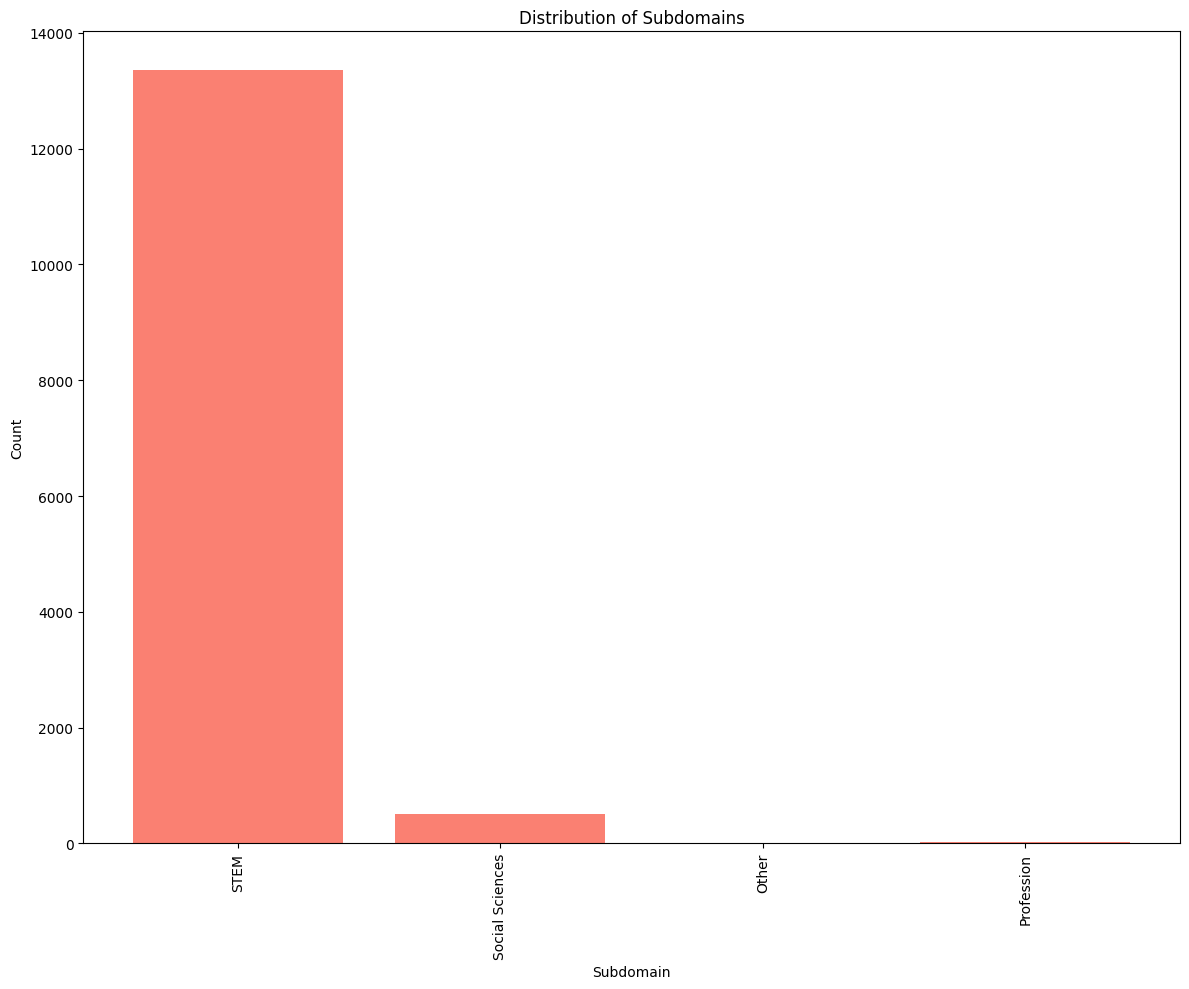

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

subdomains = [item['domain'] for item in data]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
with open("2-processed/ustad_360_stem.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)